# Soal ML 
## prediksi diagnosa Diabetes dengan Machine Learning supervised learning
Untuk memprediksi diagnosis diabetes menggunakan Supervised Learning, kita biasanya menggunakan data klinis pasien (seperti kadar gula darah, tekanan darah, usia, dan indeks massa tubuh) untuk melatih model agar bisa mengklasifikasikan apakah seorang pasien Positif Diabetes (1) atau Negatif Diabetes (0).

## 1. Alur Kerja (Workflow) Data
Sebelum masuk ke kode, berikut adalah bagaimana data diproses di dalam sistem:

1. Fitur (X): Variabel medis pasien (Gula Darah, BMI, Tekanan Darah, Umur).

2. Label (y): Target diagnosis (0 = Sehat, 1 = Diabetes).

3. Pipeline: Mengisi data kosong (jika ada), menyamakan skala angka, lalu mengklasifikasikannya.

## 1. Data collection dan EDA (Exploratory Data Analysis)

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# =====================================================================
# 1. MEMBUAT DATASET MEDIS SIMULASI (Data Historis Pasien)
# =====================================================================
# Fitur: [Glukosa, TekananDarah, BMI, Umur]
data_pasien = {
    'Glukosa': [85, 168, 89, 137, 116, 78, 115, 197, 125, 140],
    'TekananDarah': [66, 74, 60, 40, 74, 50, 0, 70, 96, 85], # Angka 0 di tekanan darah dianggap data korup/hilang
    'BMI': [26.6, 31.0, 28.1, 43.1, 25.6, 31.0, 35.3, 30.5, 0.0, 37.4],
    'Umur': [31, 54, 21, 33, 30, 26, 29, 53, 54, 41],
    'Diabetes': [0, 1, 0, 1, 0, 0, 0, 1, 1, 1] # 0 = Negatif, 1 = Positif
}

df = pd.DataFrame(data_pasien)
display(df)

,Glukosa,TekananDarah,BMI,Umur,Diabetes
0,85,66,26.6,31,0
1,168,74,31.0,54,1
2,89,60,28.1,21,0
3,137,40,43.1,33,1
4,116,74,25.6,30,0
5,78,50,31.0,26,0
6,115,0,35.3,29,0
7,197,70,30.5,53,1
8,125,96,0.0,54,1
9,140,85,37.4,41,1


In [3]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Create age groups
age_bins = [0, 25, 40, 60, 100] # Define age bin edges
age_labels = ['<25', '25-40', '40-60', '>60'] # Labels for age bins
X_with_age_group = df.copy()
X_with_age_group['Kelompok Usia'] = pd.cut(X_with_age_group['Umur'], bins=age_bins, labels=age_labels, right=False)

# Features to plot (excluding 'Umur' itself, as it's used for grouping)
features_to_plot = ['Glukosa', 'TekananDarah', 'BMI']

display(X_with_age_group)
num_features_to_plot = len(features_to_plot)

# Determine the number of rows and columns for subplots
rows = (num_features_to_plot + 1) // 2
cols = 2 if num_features_to_plot > 1 else 1

,Glukosa,TekananDarah,BMI,Umur,Diabetes,Kelompok Usia
0,85,66,26.6,31,0,25-40
1,168,74,31.0,54,1,40-60
2,89,60,28.1,21,0,<25
3,137,40,43.1,33,1,25-40
4,116,74,25.6,30,0,25-40
5,78,50,31.0,26,0,25-40
6,115,0,35.3,29,0,25-40
7,197,70,30.5,53,1,40-60
8,125,96,0.0,54,1,40-60
9,140,85,37.4,41,1,40-60


###  Buatlah visualisasi data dengan plotly "Distribusi Fitur Menggunakan Subplot Plotly"


In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


num_features_to_plot = len(features_to_plot)

# Determine the number of rows and columns for subplots
rows = (num_features_to_plot + 1) // 2
cols = 2 if num_features_to_plot > 1 else 1

fig = make_subplots(rows=rows, cols=cols,
                    subplot_titles=[f'Distribusi {col} berdasarkan Kelompok Usia' for col in features_to_plot])

# Add histograms for each feature, colored by age group
for i, feature in enumerate(features_to_plot):
    row_idx = (i // cols) + 1
    col_idx = (i % cols) + 1

    # Iterate through each age group to add a trace
    for age_group_label in age_labels:
        filtered_data = X_with_age_group[X_with_age_group['Kelompok Usia'] == age_group_label]

        # Use `histnorm='percent'` to compare distributions across groups more easily
        fig.add_trace(go.Histogram(x=filtered_data[feature], name=f'{age_group_label}', histnorm='percent', opacity=0.7),
                      row=row_idx, col=col_idx)

    fig.update_xaxes(title_text=feature, row=row_idx, col=col_idx)
    fig.update_yaxes(title_text='Persentase', row=row_idx, col=col_idx)

fig.update_layout(height=400 * rows,
                  title_text="Distribusi Fitur Berdasarkan Kelompok Usia",
                  barmode='overlay', # Overlay histograms for different age groups
                  showlegend=True, # Show legend for age groups
                  legend_title_text='Kelompok Usia')
fig.show()

## 2. MEMBUAT MODEL SUPERVISED LEARNING

In [9]:
# Mengganti nilai 0 yang tidak masuk akal pada medis (Tekanan Darah & BMI) menjadi NaN
df['TekananDarah'] = df['TekananDarah'].replace(0, np.nan)
df['BMI'] = df['BMI'].replace(0.0, np.nan)

# Pisahkan Fitur (X) dan Target/Label (y)
X = df[['Glukosa', 'TekananDarah', 'BMI', 'Umur']]
y = df['Diabetes'] # Now 'y' is defined

# Bagi data menjadi 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# =====================================================================
# 3. MEMBUAT PIPELINE SUPERVISED LEARNING
# =====================================================================
diabetes_pipeline = Pipeline([
    # Langkah 1: Mengisi nilai NaN (0 yang tidak masuk akal) dengan nilai median kolom tersebut
    ('imputer', SimpleImputer(strategy='median')),

    # Langkah 2: Menyamakan skala data agar model tidak bias (Penting untuk algoritma ML)
    ('scaler', StandardScaler()),

    # Langkah 3: Algoritma Klasifikasi Supervised Learning
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

import pickle

# =====================================================================
# MENYIMPAN MODEL PIPELINE
# =====================================================================
# Simpan pipeline yang sudah terlatih ke dalam file
model_filename = 'diabetes_pipeline.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(diabetes_pipeline, file)

print(f"Model pipeline berhasil disimpan sebagai '{model_filename}'")

Model pipeline berhasil disimpan sebagai 'diabetes_pipeline.pkl'


## 3. PROSES PELATIHAN (TRAINING)

In [10]:
# =====================================================================
# 4. PROSES PELATIHAN (TRAINING)
# =====================================================================
# Model mempelajari karakteristik pasien diabetes vs pasien sehat
diabetes_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['Glukosa','TekananDarah','BMI','Umur']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be 

## 4. EVALUASI MODEL

In [13]:
import pickle

# =====================================================================
# MEMUAT MODEL PIPELINE DAN MELATIH ULANG
# =====================================================================
# Muat pipeline yang sudah terlatih dari file
model_filename = 'diabetes_pipeline.pkl'
with open(model_filename, 'rb') as file:
    loaded_pipeline = pickle.load(file)

print(f"Model pipeline berhasil dimuat dari '{model_filename}'.")

# Latih ulang pipeline yang dimuat (menggunakan data pelatihan yang sama)
# X_train dan y_train diasumsikan masih tersedia dari eksekusi sel sebelumnya.
loaded_pipeline.fit(X_train, y_train)

print("Model pipeline yang dimuat berhasil dilatih ulang.")




Model pipeline berhasil dimuat dari 'diabetes_pipeline.pkl'.
Model pipeline yang dimuat berhasil dilatih ulang.


=== EVALUASI MODEL DENGAN CONFUSION MATRIX & AKURASI ===


Akurasi Model: 1.00
Confusion Matrix:
[[1 0]
 [0 1]]


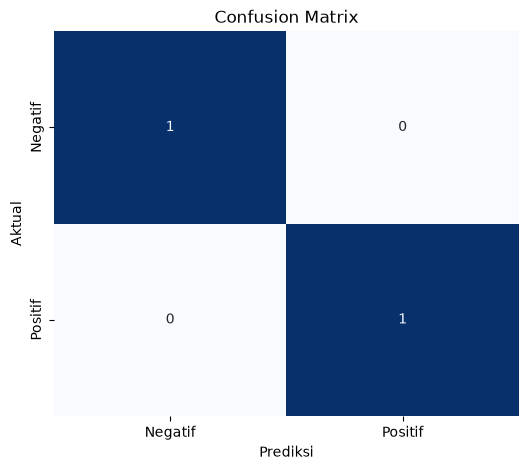

Akurasi Model: 100.00%


In [15]:
import pickle
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the trained model pipeline if not already loaded (to fix NameError)
try:
    # Check if loaded_pipeline is defined and not None. If not, load it.
    if 'loaded_pipeline' not in locals() or loaded_pipeline is None:
        with open('diabetes_pipeline.pkl', 'rb') as file:
            loaded_pipeline = pickle.load(file)
        print("Model pipeline 'diabetes_pipeline.pkl' loaded successfully within this cell.")
except FileNotFoundError:
    print("Error: Model file 'diabetes_pipeline.pkl' not found. Please ensure the model is saved correctly by running previous cells.")
    # If the model file is not found, we cannot proceed, so re-raise the error
    raise
except Exception as e:
    print(f"Error loading model pipeline: {e}")
    raise

# Asumsikan X_test dan y_test sudah tersedia dari sel sebelumnya
# Ensure these variables are defined by running appropriate preceding cells.

y_pred = loaded_pipeline.predict(X_test)

print("=== EVALUASI MODEL DENGAN CONFUSION MATRIX & AKURASI ===\n")

# Hitung Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAkurasi Model: {accuracy:.2f}")
print("Confusion Matrix:")
print(cm)




# Tampilkan Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

# Hitung dan tampilkan akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")


## 5. IMPLEMENTASI: FORM INPUTAN INTERAKTIF PREDIKSI PASIEN BARU DI KLINIK

In [12]:
# =====================================================================
# 6. IMPLEMENTASI: PREDIKSI PASIEN BARU DI KLINIK
# =====================================================================
# Datang pasien baru dengan data medis sebagai berikut:
# Glukosa: 160, Tekanan Darah: 80, BMI: 34.2, Umur: 45
pasien_baru = pd.DataFrame([
    {
    'Glukosa': 160,
    'TekananDarah': 80,
    'BMI': 34.2,
    'Umur': 45
}])

# Lakukan prediksi langsung lewat pipeline
prediksi_pasien = diabetes_pipeline.predict(pasien_baru)
probabilitas_pasien = diabetes_pipeline.predict_proba(pasien_baru)

print("=== HASIL DIAGNOSA OTOMATIS ===")
if prediksi_pasien[0] == 1:
    print(f"Hasil: POSITIF DIABETES")
    print(f"Tingkat Risiko: {probabilitas_pasien[0][1] * 100:.1f}%")
else:
    print(f"Hasil: NEGATIF DIABETES")
    print(f"Tingkat Risiko: {probabilitas_pasien[0][1] * 100:.1f}% (Rendah)")

=== HASIL DIAGNOSA OTOMATIS ===
Hasil: POSITIF DIABETES
Tingkat Risiko: 94.0%
